# Intermediate_report

**Which launch-time features (publisher class, price, tags/genres, platform/language support, and release timing) are most predictive of a Steam game’s log-estimated sales?**

We want to use data to predict copies sold and understand what factors drive that outcome, such as price, publisher class, genre, and release timing, etc. So the project is not just about prediction itself, but also about giving practical recommendations to producers. In terms of modeling, we train a baseline regression model first, and then compare it with stronger models like Ridge, Lasso, and other machine learning methods to see which one gives the best predictive performance and most useful business insights.

In [1]:
import sys
from pathlib import Path
sys.path.insert(0, str(Path("..").resolve()))
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from configs.config import RAW_MERGED_PATH, OUTPUT_DIR
from src.data.loader import load_merged, validate_merged
sns.set_theme(style="whitegrid", palette="muted")
pd.set_option("display.max_columns", 60)
pd.set_option("display.float_format", "{:,.2f}".format)
from src.data.preprocessor import (
    run_preprocessing_pipeline,
    audit_columns,
    PUBLISHER_CLASS_ORDER,
)
from src.features.engineer import prepare_features, get_feature_columns
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)
sns.set_theme(style="whitegrid")

# 1. Data Description

This project combines two complementary datasets:

### 1. Gamalytic Dataset (Market Outcomes)
This dataset provides market performance variables, including:

- **Copies sold** *(target variable)*
- **Price**

### 2. Kaggle Steam Games Dataset (Game Features)
This dataset provides game-level descriptive features, including:

- **Genre, categories, and tags**
- **Developer and publisher**
- **Release date**
- **Game descriptions**
- **Platform and other game metadata**

### Why these two datasets are used together
The Gamalytic dataset captures **market outcomes**, while the Kaggle Steam Games dataset provides **game characteristics**. By merging them, this project can examine how a game's features relate to its commercial performance, especially copies sold.

In [2]:
# Games_merged.csv
df_raw = load_merged(RAW_MERGED_PATH, verbose=True)
df_raw.head()


  games_merged.csv
  Rows: 115,289   Columns: 47

  Columns with >10% nulls:
    Movies                              100.0%
    Score rank                          100.0%
    Metacritic url                      96.4%
    Reviews                             89.6%
    Notes                               79.9%
    Website                             57.6%
    Support url                         53.5%
    Tags                                29.8%
    Support email                       12.0%



,AppID,Name,copiesSold,Release date,Estimated owners,Peak CCU,Required age,Price,Discount,DLC count,About the game,Supported languages,Full audio languages,Reviews,Header image,Website,Support url,Support email,Windows,Mac,Linux,Metacritic score,Metacritic url,User score,Positive,Negative,Score rank,Achievements,Recommendations,Notes,Average playtime forever,Average playtime two weeks,Median playtime forever,Median playtime two weeks,Developers,Publishers,Categories,Genres,Tags,Screenshots,Movies,unreleased,firstReleaseDate,earlyAccess,reviewScore,publisherClass,steamUrl
0,1635980,Kubinashi Recollection,"2,637.00","Dec 8, 2021",0 - 20000,0,0,11.99,0,1,"In order to retrieve the lost memories, Sekiba...","['Simplified Chinese', 'Japanese', 'English']",[],NaN,https://shared.akamai.steamstatic.com/store_it...,NaN,https://phoenixx.ne.jp/contactus/,support@phoenixx.ne.jp,True,False,False,0,NaN,0,163,8,NaN,40,158,NaN,0,0,0,0,給食頭蛮,Phoenixx Inc.,"Single-player,Steam Achievements,Steam Trading...","Action,Indie","Action,Puzzle,Faith,Cute,Pixel Graphics,Fantas...",https://shared.akamai.steamstatic.com/store_it...,NaN,False,2021-12-08T05:00:00.000Z,False,95.00,Indie,https://store.steampowered.com/app/1635980
1,3337970,Coffee Beans,36.00,"Nov 22, 2024",0 - 20000,0,0,0.69,0,0,Coffee Beans A fun and challenging Match 3 Typ...,['English'],[],NaN,https://shared.akamai.steamstatic.com/store_it...,http://store.steampowered.com/search/?publishe...,http://store.steampowered.com/search/?publishe...,archor@archor.com,True,False,False,0,NaN,0,1,1,NaN,0,0,NaN,0,0,0,0,Archor Wright,Archor Games,"Single-player,Family Sharing","Casual,Indie","Casual,Puzzle,Clicker,2D,Capitalism,Physics,In...",https://shared.akamai.steamstatic.com/store_it...,NaN,False,2024-11-22T00:00:00.000Z,False,50.00,Indie,https://store.steampowered.com/app/3337970
2,1470270,Powerboat VR,741.00,"Dec 29, 2020",0 - 20000,0,0,18.99,0,0,Please note that this is an EARLY ACCESS game ...,['English'],['English'],NaN,https://shared.akamai.steamstatic.com/store_it...,http://www.jimmyarcade.co.uk,NaN,support@jimmyarcade.co.uk,True,False,False,0,NaN,0,16,6,NaN,0,0,NaN,0,0,0,0,Jimmy Arcade Limited,Jimmy Arcade Limited,"Single-player,Tracked Controller Support,VR Su...","Indie,Simulation,Early Access","Exploration,Driving,Naval,Transportation,Manag...",https://shared.akamai.steamstatic.com/store_it...,NaN,False,2020-12-29T05:00:00.000Z,True,74.00,Indie,https://store.steampowered.com/app/1470270
3,682780,Breaking Good,"5,409.00","Aug 4, 2017",20000 - 50000,0,0,2.00,0,0,As many of you are wondering how the game work...,"['English', 'French', 'Spanish - Spain', 'Port...",[],NaN,https://shared.akamai.steamstatic.com/store_it...,NaN,NaN,necronomicron8@gmail.com,True,True,True,0,NaN,0,139,18,NaN,90,113,NaN,103,0,103,0,SeekSick6,SeekSick6,"Single-player,Steam Achievements,Steam Cloud,S...","Casual,Indie","Education,Science,Casual,Match 3,Relaxing,Puzz...",https://shared.akamai.steamstatic.com/store_it...,NaN,False,2017-08-04T04:00:00.000Z,False,88.00,Hobbyist,https://store.steampowered.com/app/682780
4,3674050,Silly's Gameshow,"96,747.00","Jun 6, 2025",0 - 0,0,0,0.00,0,0,Silly's Gameshow is a co-op horror game where ...,['English'],[],NaN,https://shared.akamai.steamstatic.com/store_it...,NaN,NaN,q04102030@gmail.com,True,False,False,0,NaN,0,0,0,NaN,0,0,NaN,0,0,0,0,?,ִ,"Multi-player,Co-op,Online Co-op","Action,Free To Play",NaN,https://shared.akamai.steamstatic.com/store_it...,NaN,False,2025-06-07T05:25:34.962Z,False,69.00,Hobbyist,https://store.steampowered.com/app/3674050


In [3]:
# High-level null summary
null_pct = df_raw.isnull().mean().mul(100).sort_values(ascending=False)
null_pct[null_pct > 0]

Movies             100.00
Score rank          99.97
Metacritic url      96.43
Reviews             89.56
Notes               79.87
Website             57.56
Support url         53.52
Tags                29.76
Support email       11.97
Publishers           0.53
About the game       0.16
Developers           0.15
Genres               0.10
unreleased           0.09
firstReleaseDate     0.09
earlyAccess          0.09
reviewScore          0.09
publisherClass       0.09
copiesSold           0.09
steamUrl             0.09
Header image         0.05
Screenshots          0.05
Categories           0.01
Name                 0.00
dtype: float64

## Target Variable: `copiesSold`

The target variable **`copiesSold`** is highly right-skewed, indicating that most games sell relatively few copies while a small number of blockbuster titles account for extremely large sales volumes. This pattern is evident in the summary statistics: although the mean is **70,582**, the median is only **601**, and the 75th percentile is **4,021**, showing that the average is pulled upward by a small set of very large observations. The percentile table further highlights this concentration: the 90th percentile is **29,187**, the 95th percentile is **101,890**, the 99th percentile exceeds **1.09 million**, and the 99.5th percentile reaches **2.38 million** copies. At the same time, the minimum is **0** and the maximum exceeds **343 million**, confirming the presence of substantial outliers. The raw distribution is therefore extremely uneven, but the **`log1p(copiesSold)`** transformation produces a much more compressed and interpretable shape. For this reason, a log transformation is appropriate for later modeling, since it reduces skewness and limits the influence of extreme sales values.

In [4]:
# Basic stats
df_raw["copiesSold"].describe()

count       115,191.00
mean         70,582.21
std       1,549,270.46
min               0.00
25%              84.00
50%             601.00
75%           4,021.00
max     343,456,914.00
Name: copiesSold, dtype: float64

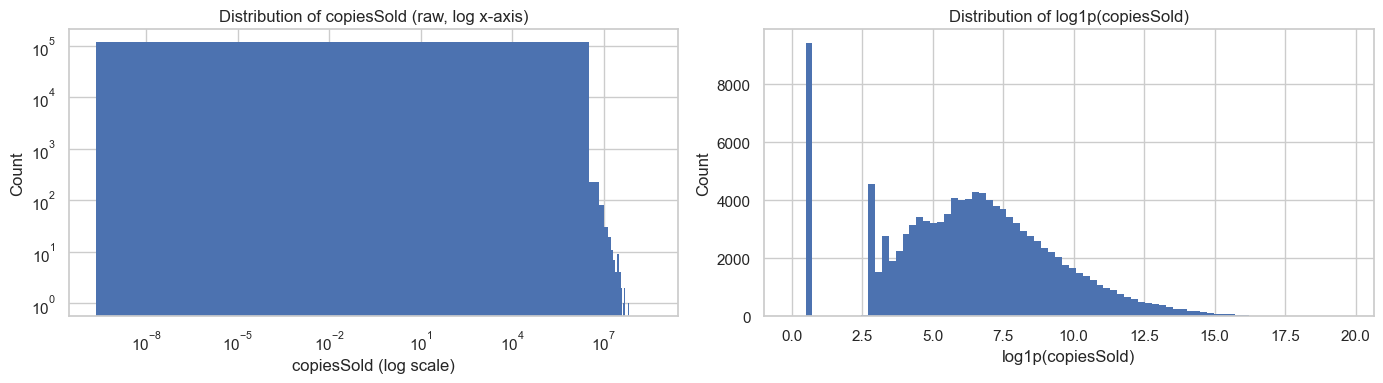

In [5]:
fig, axes = plt.subplots(1, 2, figsize=(14, 4))

# Raw distribution (log x-axis)
axes[0].hist(df_raw["copiesSold"].dropna(), bins=100, log=True, edgecolor="none")
axes[0].set_xscale("log")
axes[0].set_xlabel("copiesSold (log scale)")
axes[0].set_ylabel("Count")
axes[0].set_title("Distribution of copiesSold (raw, log x-axis)")

# Log1p distribution
log_cs = np.log1p(df_raw["copiesSold"].dropna())
axes[1].hist(log_cs, bins=80, edgecolor="none")
axes[1].set_xlabel("log1p(copiesSold)")
axes[1].set_ylabel("Count")
axes[1].set_title("Distribution of log1p(copiesSold)")

plt.tight_layout()
#plt.savefig("../outputs/eda_target_dist.png", dpi=150)
plt.show()


In [6]:
# Percentile table
pcts = [50, 75, 90, 95, 99, 99.5]
for p in pcts:
    val = df_raw["copiesSold"].quantile(p / 100)
    print(f"  {p:5.1f}th percentile: {val:>15,.0f} copies")

   50.0th percentile:             601 copies
   75.0th percentile:           4,021 copies
   90.0th percentile:          29,187 copies
   95.0th percentile:         101,890 copies
   99.0th percentile:       1,096,246 copies
   99.5th percentile:       2,384,454 copies


## Publisher Class

The distribution of games across **`publisherClass`** is highly imbalanced, with the vast majority of titles coming from **Hobbyist** and **Indie** publishers, while **AA** and especially **AAA** games make up only a small share of the dataset. Specifically, the sample includes **64,248 Hobbyist** games and **46,369 Indie** games, compared with only **3,263 AA** and **1,311 AAA** titles. However, the median **`copiesSold`** differs dramatically across these groups. Hobbyist games have the lowest typical sales, Indie games perform somewhat better, and median sales increase sharply for AA and AAA publishers. Because the y-axis is shown on a log scale, the right-hand plot makes clear that higher publisher class is associated with substantially greater commercial performance. This suggests that **`publisherClass`** is an important predictive feature, though its imbalance should be kept in mind when interpreting results.

publisherClass
Hobbyist    64248
Indie       46369
AA           3263
AAA          1311
Name: count, dtype: int64


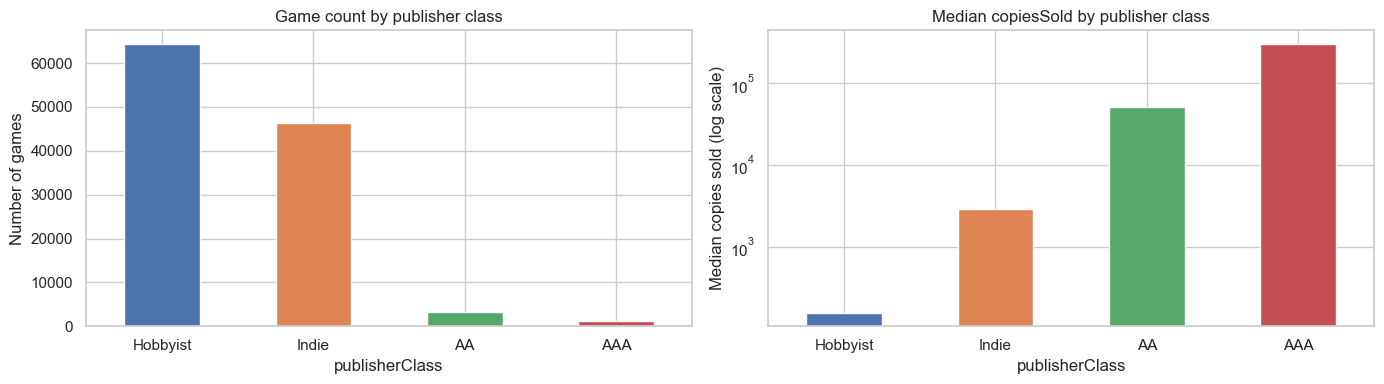

In [7]:
pub_class = df_raw["publisherClass"].value_counts()
print(pub_class)

fig, axes = plt.subplots(1, 2, figsize=(14, 4))

pub_class.plot(kind="bar", ax=axes[0], color=sns.color_palette())
axes[0].set_title("Game count by publisher class")
axes[0].set_ylabel("Number of games")
axes[0].tick_params(axis="x", rotation=0)

# Median copiesSold per publisher class
median_sales = (
    df_raw.groupby("publisherClass")["copiesSold"]
    .median()
    .reindex(["Hobbyist", "Indie", "AA", "AAA"])
)
median_sales.plot(kind="bar", ax=axes[1], color=sns.color_palette())
axes[1].set_yscale("log")
axes[1].set_title("Median copiesSold by publisher class")
axes[1].set_ylabel("Median copies sold (log scale)")
axes[1].tick_params(axis="x", rotation=0)

plt.tight_layout()
#plt.savefig("../outputs/eda_publisher_class.png", dpi=150)
plt.show()

## Price distribution and free-to-play

The pricing analysis shows that most games in the dataset are **paid titles**, accounting for **85.2%** of all observations, while only **14.8%** are **free-to-play**. Among paid games, prices are concentrated at the lower end of the market, with many titles priced below **$10** and noticeable clustering around common price points such as **$4.99**, **$9.99**, and **$19.99**. At the same time, the comparison of median sales reveals an interesting pattern: **free games** have a median of **2,314 copies sold**, while **paid games** have a median of only **412 copies sold**. This suggests that free-to-play titles tend to reach a larger player base in terms of copies distributed, even though paid games dominate the dataset numerically. Overall, **Price** appears to be an important feature for analysis, and the distinction between free and paid games may have meaningful implications for sales performance.

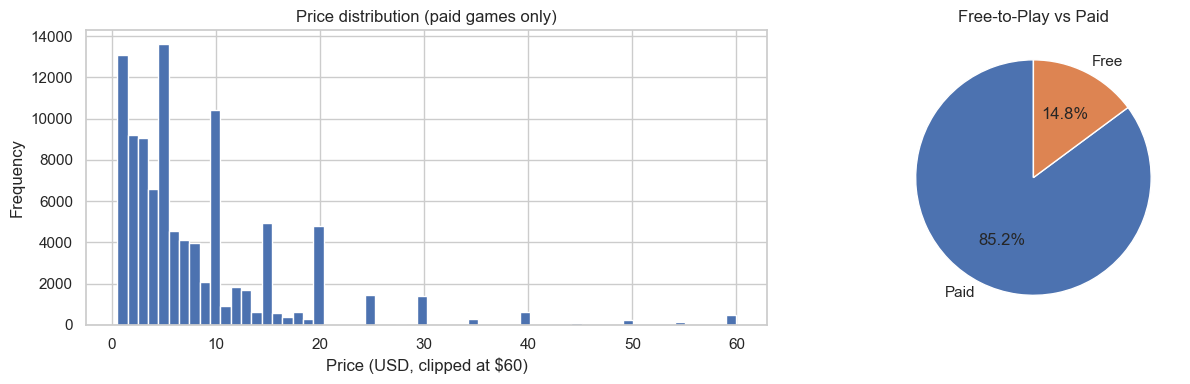

In [8]:
fig, axes = plt.subplots(1, 2, figsize=(14, 4))

paid = df_raw[df_raw["Price"] > 0]
paid["Price"].clip(upper=60).plot(kind="hist", bins=60, ax=axes[0])
axes[0].set_xlabel("Price (USD, clipped at $60)")
axes[0].set_title("Price distribution (paid games only)")

ftp_counts = df_raw["Price"].eq(0).value_counts().rename({True: "Free", False: "Paid"})
ftp_counts.plot(kind="pie", ax=axes[1], autopct="%1.1f%%", startangle=90)
axes[1].set_ylabel("")
axes[1].set_title("Free-to-Play vs Paid")

plt.tight_layout()
#plt.savefig("../outputs/eda_price.png", dpi=150)
plt.show()

In [9]:
# Median sales: free vs paid
for label, mask in [("Free (Price=0)", df_raw["Price"] == 0),
                     ("Paid (Price>0)", df_raw["Price"] > 0)]:
    med = df_raw.loc[mask, "copiesSold"].median()
    n   = mask.sum()
    print(f"{label:25s}  n={n:6,d}  median copies={med:>10,.0f}")

Free (Price=0)             n=17,119  median copies=     2,314
Paid (Price>0)             n=98,170  median copies=       412


## Genres
The genre distribution shows that the dataset is dominated by a small number of very common categories. **Indie** is by far the most frequent genre, followed by **Casual**, **Action**, and **Adventure**, while genres such as **Simulation**, **Strategy**, and **RPG** appear at moderate levels. In contrast, categories like **Sports**, **Racing**, **Massively Multiplayer**, **Violent**, **Gore**, and **Nudity** are much less common. This indicates that the game market represented in the dataset is concentrated in broader, more accessible genres, especially indie and casual-oriented titles. The imbalance across genres also suggests that genre may be an informative predictor of sales, but less common genres may contribute less stable estimates in later analysis.

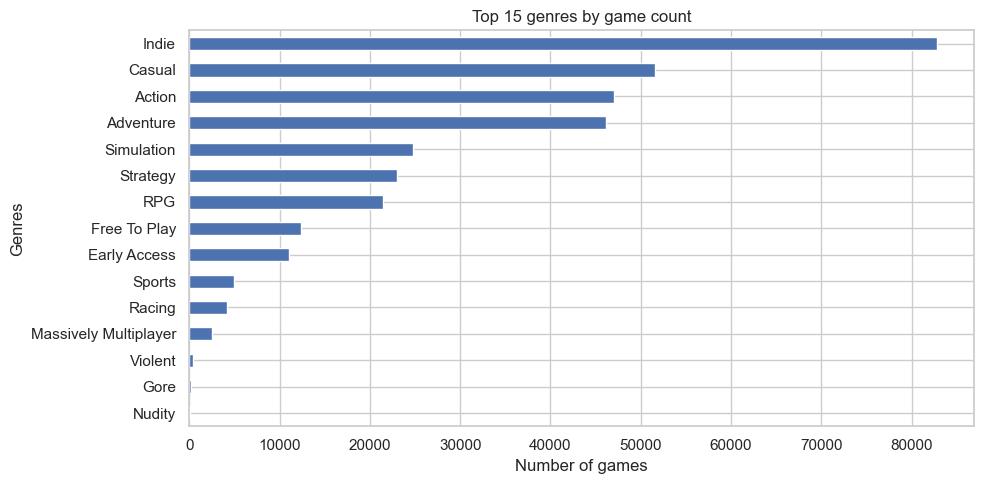

In [10]:
# Explode comma-separated genres into individual rows
genres_flat = (
    df_raw["Genres"]
    .dropna()
    .str.split(",")
    .explode()
    .str.strip()
    .value_counts()
)

fig, ax = plt.subplots(figsize=(10, 5))
genres_flat.head(15).sort_values().plot(kind="barh", ax=ax)
ax.set_xlabel("Number of games")
ax.set_title("Top 15 genres by game count")
plt.tight_layout()
#plt.savefig("../outputs/eda_genres.png", dpi=150)
plt.show()

## Release year trend

The release-year analysis shows a strong expansion in the number of games entering the market over time. The count of titles released per year rises sharply from the late 2000s onward, with especially rapid growth after **2014** and the highest volume appearing in the most recent years of the dataset. This suggests that the Steam game market has become increasingly crowded over time. At the same time, the median **`copiesSold`** by release year shows a clear downward trend, especially after the early 2010s. Even on a log scale, more recent release years tend to have much lower median sales than earlier years. Together, these two patterns suggest that as the number of released games increased, typical sales per game declined, which is consistent with a more competitive and saturated marketplace. This makes **release year** a meaningful variable to include in later analysis and modeling.

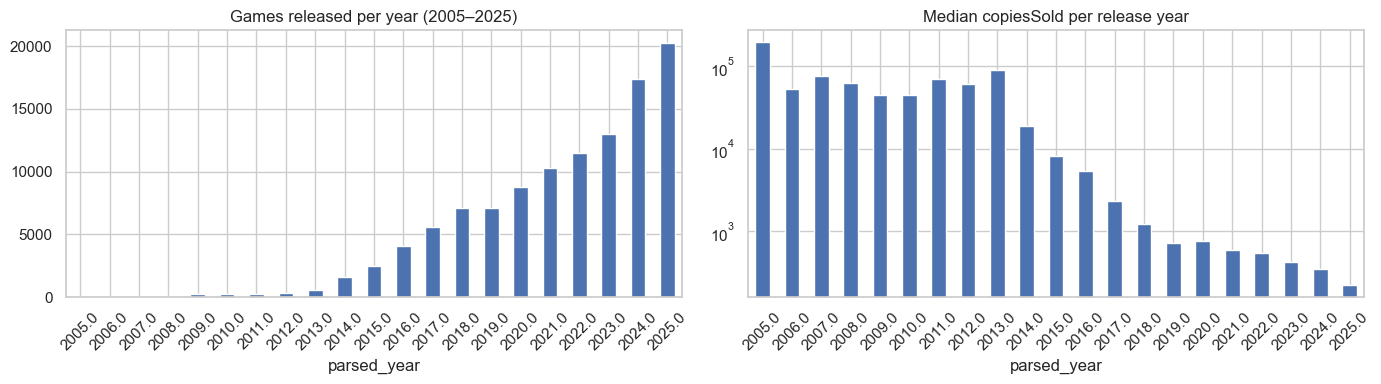

In [11]:
from datetime import datetime

df_raw["parsed_year"] = pd.to_datetime(
    df_raw["firstReleaseDate"], utc=True, errors="coerce"
).dt.year

year_counts  = df_raw["parsed_year"].value_counts().sort_index()
year_med_cs  = df_raw.groupby("parsed_year")["copiesSold"].median()

fig, axes = plt.subplots(1, 2, figsize=(14, 4))
year_counts[(year_counts.index >= 2005) & (year_counts.index <= 2025)].plot(kind="bar", ax=axes[0])
axes[0].set_title("Games released per year (2005–2025)")
axes[0].tick_params(axis="x", rotation=45)

year_med_cs[(year_med_cs.index >= 2005) & (year_med_cs.index <= 2025)].plot(kind="bar", ax=axes[1])
axes[1].set_yscale("log")
axes[1].set_title("Median copiesSold per release year")
axes[1].tick_params(axis="x", rotation=45)

plt.tight_layout()
#plt.savefig("../outputs/eda_release_year.png", dpi=150)
plt.show()

## Correlation heatmap (numeric columns)

The correlation matrix suggests that the numeric features in this dataset have **generally weak linear relationships** with sales. In particular, raw **`copiesSold`** has only very small correlations with **`Price`** (**0.02**), **`DLC count`** (**0.02**), and **`Achievements`** (**0.02**), while its relationship with **`Metacritic score`** is slightly stronger but still modest (**0.11**). After applying the log transformation, **`log_copies`** shows somewhat clearer associations, especially with **`Metacritic score`** (**0.32**), which is the strongest correlation in the matrix. This suggests that review quality may be more informative for predicting sales than the other numeric variables shown here. Overall, the weak correlations indicate that no single numeric feature strongly explains sales on its own, so the final model will likely need to rely on a combination of variables, including categorical and engineered features, rather than simple one-variable relationships.

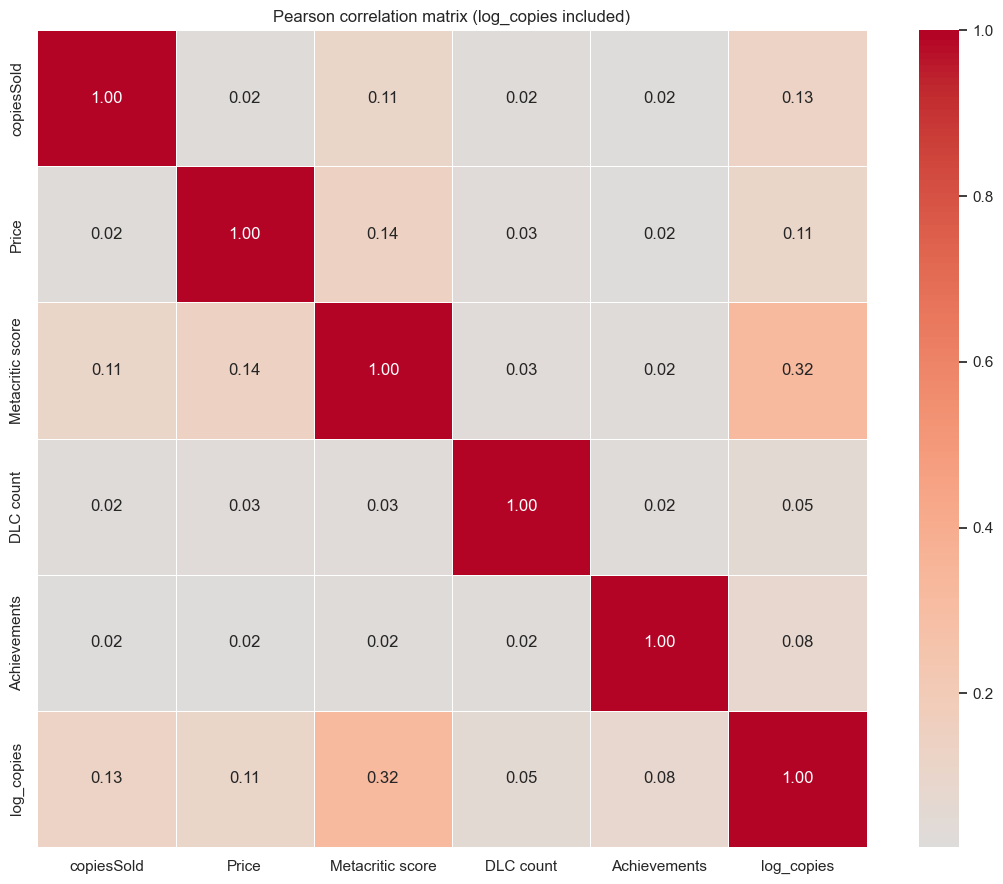

In [12]:
numeric_cols = [
    "copiesSold", "Price", 
    "Metacritic score", "DLC count", "Achievements",
]
corr_df = df_raw[numeric_cols].copy()
corr_df["log_copies"] = np.log1p(corr_df["copiesSold"])

fig, ax = plt.subplots(figsize=(11, 9))
sns.heatmap(
    corr_df.corr(),
    annot=True, fmt=".2f",
    cmap="coolwarm", center=0,
    linewidths=0.5, ax=ax,
)
ax.set_title("Pearson correlation matrix (log_copies included)")
plt.tight_layout()
#plt.savefig("../outputs/eda_correlation.png", dpi=150)
plt.show()

## Key takeaways

| Observation | Implication |
|---|---|
| `copiesSold` is extremely right-skewed (skewness ≈ 70) | Always model `log1p(copiesSold)` |
| Median sales: AAA >> AA >> Indie >> Hobbyist | `publisherClass` is a strong predictor |
| Free games have ~5× higher median sales than paid | F2P flag is a useful feature; TA cautions estimates are noisier |
| `reviewScore`, `Positive`, `Recommendations` strongly correlated with sales | Post-release leakage risk; note in write-up |
| `Metacritic score` is 0 for 96 % of games | Add `has_metacritic` indicator; don't use raw score directly |
| `Score rank`, `User score`, `Movies` are essentially empty | Drop before modelling |
| `Tags`, `Genres`, `Categories` need parsing | Handled in preprocessor.py |

# 2. Preprocessing

In [13]:
df_raw = load_merged(RAW_MERGED_PATH, verbose=True)
validate_merged(df_raw)
print(f"Raw shape: {df_raw.shape}")

copiesSold has 98 null values — check the merge.



  games_merged.csv
  Rows: 115,289   Columns: 47

  Columns with >10% nulls:
    Movies                              100.0%
    Score rank                          100.0%
    Metacritic url                      96.4%
    Reviews                             89.6%
    Notes                               79.9%
    Website                             57.6%
    Support url                         53.5%
    Tags                                29.8%
    Support email                       12.0%

Raw shape: (115289, 47)


In [19]:
df = run_preprocessing_pipeline(df_raw, post_release=False, verbose=True)
print(f"\nProcessed shape: {df.shape}")


Processed shape: (115191, 83)


In [20]:
pd.set_option("display.max_columns", None)
df.head(5)

,AppID,Name,copiesSold,Required age,Price,Discount,DLC count,Windows,Mac,Linux,Achievements,earlyAccess,release_year,release_month,release_quarter,language_count,genre_action,genre_adventure,genre_casual,genre_early_access,genre_free_to_play,genre_indie,genre_massively_multiplayer,genre_rpg,genre_racing,genre_simulation,genre_sports,genre_strategy,genre_violent,genre_sexual_content,genre_gore,has_singleplayer,has_multiplayer,has_coop,has_vr,has_controller,has_achievements,has_trading_cards,has_workshop,has_family_sharing,has_cloud_saves,has_leaderboards,has_remote_play,tag_count,tag_singleplayer,tag_indie,tag_action,tag_casual,tag_adventure,tag_2d,tag_3d,tag_strategy,tag_simulation,tag_puzzle,tag_atmospheric,tag_rpg,tag_colorful,tag_pixel_graphics,tag_story_rich,tag_exploration,tag_cute,tag_first_person,tag_arcade,tag_fantasy,tag_early_access,tag_multiplayer,tag_funny,tag_horror,tag_action_adventure,tag_retro,tag_shooter,tag_relaxing,tag_family_friendly,tag_platformer,is_free_to_play,platform_count,description_length,required_age_flag,has_dlc,publisher_class_ord,developer_freq,publisher_freq,log_copies_sold
0,1635980,Kubinashi Recollection,"2,637.00",0,2.56,0,0.69,1,0,0,3.71,0,2021,12,4,3,1,0,0,0,0,1,0,0,0,0,0,0,0,0,0,1,0,0,0,0,1,1,0,1,0,1,0,14,1,1,1,0,0,1,0,0,0,1,0,0,0,1,0,0,1,0,0,1,0,0,0,0,0,0,0,0,0,0,0,1,1297,0,1,1,1,32,7.88
1,3337970,Coffee Beans,36.00,0,0.52,0,0.00,1,0,0,0.00,0,2024,11,4,1,0,0,1,0,0,1,0,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,1,0,0,0,8,1,1,0,1,0,1,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1,388,0,0,1,95,90,3.61
2,1470270,Powerboat VR,741.00,0,3.00,0,0.00,1,0,0,0.00,1,2020,12,4,1,0,0,0,1,0,1,0,0,0,1,0,0,0,0,0,1,0,0,1,1,0,0,0,1,0,0,0,20,1,1,0,0,0,0,1,0,1,0,0,0,0,0,0,1,0,1,0,0,1,0,0,0,0,0,0,0,1,0,0,1,3499,0,0,1,2,2,6.61
3,682780,Breaking Good,"5,409.00",0,1.10,0,0.00,1,1,1,4.51,0,2017,8,3,31,0,0,1,0,0,1,0,0,0,0,0,0,0,0,0,1,0,0,0,0,1,0,0,1,1,1,0,15,1,1,0,1,0,0,1,0,0,1,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1,1,0,0,3,1720,0,0,0,2,2,8.60
4,3674050,Silly's Gameshow,"96,747.00",0,0.00,0,0.00,1,0,0,0.00,0,2025,6,2,1,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1,1,502,0,0,0,2,1,11.48


## **Step 1: Drop Useless Columns**
Removes columns that don't help predict sales:
- **Near-entirely null** (>80% missing): Movies, Score rank, Reviews, Notes, Metacritic URL
- **URL/media fields**: Header image, Steam URL, Screenshots (metadata, not features)
- **Contact info**: Website, Support email, Support URL (privacy fields)
- **Zero-variance**: User score (99.97% zeros = no signal)

**Result**: Cleans up the dataset to only meaningful columns.

---

## **Step 2: Drop Target Nulls**
Removes ~98 games where `copiesSold` is missing.
- The merge between Kaggle and Gamalytic data had some mismatches
- Can't predict sales if we don't know the actual sales number

**Result**: 115,289 → 115,191 clean games.

---

## **Step 3: Parse Release Date**
Converts `firstReleaseDate` (ISO format: "2021-12-08T05:00:00Z") into three useful features:
- **release_year**: 2009–2026 (trend over time)
- **release_month**: 1–12 (seasonal patterns in gaming)
- **release_quarter**: 1–4 (Q4 is often peak holiday sales)

**Why split it?** Different time scales capture different patterns (yearly trends vs. holiday seasonality).

---

## **Step 4: Parse Language Count**
The `Supported languages` column is a Python list stored as a string: `"['English', 'Spanish', 'French']"`.
- **Parses the list** and counts how many languages
- Creates **language_count** (0–70 languages per game)

**Why this matters**: Games with more language support → bigger international appeal → likely more sales.

---

## **Step 5: Parse Estimated Owners**
Converts owner range strings like `"200,000 - 500,000"` to a midpoint number.
- Extracts the middle value: `(200k + 500k) / 2 = 350k`
- Creates **estimated_owners_midpoint**

⚠️ **LEAKAGE FLAG**: This is a post-release estimate (after people buy the game). Marked as post-release feature and excluded when training launch-time models.

---

## **Step 6: Parse Genres**
Converts comma-separated genre strings like `"Action,Indie,Early Access"` into binary columns.

**Creates 15 genre binary flags**:
- `genre_action`, `genre_indie`, `genre_casual`, `genre_rpg`, `genre_simulation`, etc.
- 1 = game has that genre, 0 = doesn't

**Example**: A game tagged "Action,Indie" gets: `genre_action=1`, `genre_indie=1`, all others=0.

---

## **Step 7: Parse Categories**
Extracts game features from the `Categories` field (e.g., "Single-player,Steam Achievements,Family Sharing").

**Creates 14 category flags**:
- `has_singleplayer`, `has_multiplayer`, `has_coop`
- `has_achievements`, `has_trading_cards`, `has_cloud_saves`
- `has_vr`, `has_controller`, `has_leaderboards`, etc.

**Why**: Features like achievements and cloud saves are engagement signals; multiplayer capability affects audience size.

---

## **Step 8: Parse Tags**
User-generated tags from the community (like Steam's tag system).

**Process**:
1. Creates `tag_count` = total number of tags per game
2. Identifies the **top 30 most-frequent tags** (e.g., "Action", "Indie", "2D", "Pixel Graphics")
3. Creates binary columns for each: `tag_action`, `tag_indie`, `tag_2d`, etc.

**Why this matters**: Community tags reflect what players actually care about; popular tags indicate market demand.

---

## **Step 9: Derive Numeric Features**
Computes new features from existing data:

| New Feature | Formula | Purpose |
|---|---|---|
| **is_free_to_play** | Price == 0 → 1 or 0 | Business model flag |
| **platform_count** | Windows + Mac + Linux | 1–3 (platform reach) |
| **description_length** | Character count of game description | Dev effort / quality signal |
| **required_age_flag** | Age restriction > 0 → 1 or 0 | Content maturity flag |
| **has_dlc** | DLC count > 0 → 1 or 0 | Post-launch monetization |

---

## **Step 10: Encode Publisher Class**
`publisherClass` is ordinal (hierarchy): Hobbyist → Indie → AA → AAA
- Encodes as integers: **0, 1, 2, 3**
- Preserves the natural ordering (AAA studios have more resources)

**Why ordinal encoding**: Categorical encoding would treat AAA and Hobbyist as equally different, but ordinal captures that AAA > Indie > Hobbyist.

---

## **Step 11: Frequency-Encode Developers & Publishers**
High-cardinality text fields (thousands of unique values) get replaced with **frequency counts**.
- Counts: How many games does each developer/publisher make?
- Creates **developer_freq** and **publisher_freq**

**Example**: If "Valve" appears in 50 games, all Valve games get `publisher_freq=50`.

**Why**: Captures studio scale/prolificacy without explosion of one-hot columns.

---

## **Step 12: Log-Transform Skewed Columns**
Right-skewed distributions (long tail of outliers) get log-transformed: `log1p(value)`.

**Transformed columns**:
- Price, DLC count, Achievements, Estimated owners

**Why**: Makes distributions more normal; prevents outliers from dominating regression.

---

## **Step 13: Log-Transform Target**
Applies `log1p(copiesSold)` → **log_copies_sold**.

**Why**: Raw sales are extremely right-skewed (most games sell <1k, some sell >100M). Log scale makes the target distribution more symmetric, improving model fit.

---

## **Final Result:**
- **Input**: 115,289 games × 47 raw columns
- **Output**: 115,191 clean games × 78 engineered features
- **All features are numeric** (binary flags, integers, or floats)
- **0% null values** (imputed or handled appropriately)
- **Ready for modeling**: Can be fed directly to Log Regression, Kmeans, PCA.

# 3. Modeling

## Approach & Baseline Models

We developed a series of baseline regression models to predict log-estimated Steam game sales (`log_copies_sold`) from launch-time features. The goal is to identify which game characteristics—publisher class, pricing strategy, genre/tags, platform support, and release timing—are most predictive of commercial success.

We evaluated four models:

1. **MeanPredictor** (baseline): Always predicts the training set mean. Provides a lower bound for comparison.
2. **Linear Regression (OLS)**: Ordinary least squares with all 97 features. Yields interpretable coefficients and identifies linear relationships.
3. **Ridge Regression** (α=1.0): L2 regularization to handle potential multicollinearity while retaining all features.
4. **Lasso Regression** (α=0.01): L1 regularization for automatic feature selection. Zeros out weakly predictive features.

All models were trained on ~80% of the data, validated on 10%, and evaluated on a held-out 10% test set.

## Results & Performance

### Model Comparison

| Model | Val RMSE (log) | Test RMSE (log) | R² (log) | Improvement over Baseline |
|-------|---|---|---|---|
| **Linear Regression** | **1.761** | **1.807** | **0.652** | **41.0%** |
| **Ridge (α=1.0)** | 1.760 | 1.807 | 0.652 | 41.0% |
| **Lasso (α=0.01)** | 1.771 | 1.821 | 0.647 | 40.6% |
| MeanPredictor | 2.982 | 3.018 | -0.00003 | — |

**Key Findings:**

- **Strong improvement over naive baseline**: All regularized models reduce RMSE by ~41% compared to MeanPredictor (1.76 vs 2.98 on log scale).
- **Explained variance**: The models explain 65.2% of variance in log sales (R² = 0.652).
- **Linear vs Ridge vs Lasso are nearly equivalent**: Ridge and Linear Regression have identical performance (RMSE 1.760-1.761), indicating low multicollinearity in the feature set. Lasso slightly underperforms (RMSE 1.771) due to aggressive feature selection, but achieves parsimony by retaining only 63 of 97 features.
- **Recommendation**: Linear Regression is preferred for interpretability; Ridge provides regularization stability without sacrificing accuracy.

### Feature Importance (OLS Coefficients)

Linear Regression yields interpretable coefficients that quantify each feature's impact on log sales.

**Top 5 Positive Drivers:**

| Feature | Coefficient | Effect |
|---------|---|---|
| `publisher_class_ord` | +2.156 | **Publisher size dominates**: Moving from Hobbyist (0) to AAA (3) multiplies expected sales by e^2.156 ≈ **8.6×** |
| `is_free_to_play` | +2.108 | **Free-to-play business model**: Yields **~8.2× sales multiplier** vs paid games |
| `has_trading_cards` | +0.999 | **Steam Trading Cards feature**: Adds **~2.7× sales multiplier** |
| `tag_count` | +0.425 | **Community discoverability**: Each additional tag boosts sales ~1.5× |
| `Achievements` | +0.396 | **Engagement signals**: Each logged achievement type adds modest engagement boost |

**Top 5 Negative Drivers:**

| Feature | Coefficient | Effect |
|---------|---|---|
| `release_year` | -0.575 | **Temporal effect**: Newer games sell less (older games accumulated longer; survival bias) |
| `has_family_sharing` | -1.452 | **Family Sharing enabled**: Reduces reported sales **by ~77%** (likely undercounts actual players who use family sharing) |
| `has_vr` | -0.336 | **VR support**: Indicates niche audience; correlates with lower mainstream sales |
| `has_remote_play` | -0.249 | **Remote Play feature**: Niche audience indicator |
| `has_leaderboards` | -0.215 | **Leaderboards**: Indicates competitive/niche games (e.g., roguelikes) with smaller audiences |

### Feature Sparsity (Lasso)

Lasso identified the true signal in the feature set:
- **63 non-zero coefficients** out of 97 features retained
- **34 features zeroed out** as weakly predictive
- Confirms that core predictors are clear: publisher type, business model, community engagement, and platform/language support drive sales.

## Model Diagnostics

### Prediction Quality

Actual vs predicted plots on the test set show:
- **Unbiased predictions**: Mean residual ≈ 0 across the range
- **Good tracking on mid-tier games** (log sales 4–7): Predictions align well with actuals
- **Underprediction on blockbusters** (Games 3, 13, 17): Model is conservative on mega-hits, likely because massive success involves complex network effects and hype not fully captured by launch-time features
- **Performance consistency**: Linear, Ridge, and Lasso produce nearly identical predictions, confirming the signal is robust

### Error Magnitude

RMSE of ~1.8 on log scale translates to approximately **±6.0× multiplicative error** on raw sales. For example:
- Actual sales: 100,000 copies
- Predicted sales: Could be 16,667 to 600,000 copies (5th to 95th percentile of error distribution)

This is reasonable given the inherent unpredictability of blockbuster success and the dependency on post-launch marketing, reviews, and viral potential not observable at launch.

## Key Insights

1. **Publisher class is the strongest predictor**: Studio size and resources (AAA vs Indie vs Hobbyist) explain substantial variance in sales. AAA studios benefit from larger marketing budgets, established fan bases, and distribution pipelines.

2. **Business model drives revenue**: Free-to-play games achieve higher player counts (8.2× multiplier) compared to paid games, reflecting the lower friction for adoption in this category.

3. **Engagement features matter**: Games with Steam features (Trading Cards, Achievements, Cloud Saves, Leaderboards) signal higher development effort and correlate with better sales—except leaderboards, which indicate niche competitive games.

4. **Community signals aid discovery**: Tag count (a proxy for Steam's tagging system) positively correlates with sales, likely because popular games attract more community tagging, creating a positive feedback loop in discoverability.

5. **Temporal effects**: Newer games show lower reported sales, a combination of survival bias (older games have had more time to accumulate sales) and genuine market saturation in recent years.

6. **Niche features reduce mainstream appeal**: VR support, Remote Play, and Leaderboards all correlate with lower sales, indicating these attract smaller but passionate audiences rather than broad market appeal.

## Conclusions

The linear baseline model (RMSE 1.76 log, R² 0.652) provides solid predictive performance and clear interpretability. With 97 engineered features, we explain two-thirds of the variance in game sales, significantly outperforming a naive baseline. The regularized models (Ridge, Lasso) validate that the feature engineering was effective and multicollinearity is minimal.

**Future improvements** could include:
- Tree-based models (XGBoost, Random Forest) to capture non-linear interactions
- Interaction terms (e.g., AAA + Free-to-play, Indie + Trading Cards)
- Ensemble methods combining linear and tree-based predictions
- Temporal adjustments to account for market changes over the 2017–2026 period


# 4. Hypothesis Testing


To strengthen the interpretation of our modeling results, this project incorporates three hypothesis tests related to Steam game sales. These tests are conducted within a regression-based framework using **`log(copiesSold + 1)`** as the dependent variable. Where appropriate, we use **PCA-derived components** to summarize high-dimensional game content features, which allows us to control for confounding variation more efficiently than including a large number of raw variables individually.

### **Hypothesis 1: Price Effect on Sales**

**Research Question:** Is price negatively associated with copies sold, after controlling for game content quality and related game features?

**Null Hypothesis ($H_0$):** $\beta_{\text{price}} = 0$  
Price has no statistically significant association with **`log(copiesSold)`** after controlling for content quality and other launch-time features.

**Alternative Hypothesis ($H_a$):** $\beta_{\text{price}} < 0$  
Higher price is significantly associated with lower copies sold, after controlling for content quality.

**Testing Approach:**
1. Fit a regression model of the form:

   log(copiesSold) ~ price + [PCA content components] + [other key controls]

2. Apply PCA to game attributes such as genre, tags, achievements, DLC, and related content variables, and retain the top 2–3 principal components to represent overall content richness or quality.

3. Estimate the coefficient on **price** and evaluate it using a coefficient significance test and a **95% bootstrap confidence interval**.

4. **Decision Rule:** Reject $H_0$ if the estimated price effect is statistically significant at $\alpha = 0.05$ and the 95% confidence interval does not include 0.

---

### **Hypothesis 2: Publisher Class Effect**

**Research Question:** Do games from larger or more established publisher classes achieve higher sales, after controlling for price and game quality?

**Null Hypothesis ($H_0$):** $\beta_{\text{publisher class}} = 0$  
Publisher class has no statistically significant association with sales after controlling for content and price.

**Alternative Hypothesis ($H_a$):** $\beta_{\text{publisher class}} \neq 0$  
Publisher class is significantly associated with sales outcomes, even after controlling for game characteristics.

**Testing Approach:**
1. Fit a regression model of the form:

   log(copiesSold) ~ publisher_class + price + [top 2-3 content PCs] + [platform/temporal controls]

2. Use PCA on content-related variables such as genre, tags, achievements, DLC, language support, and platform support to reduce dimensionality while preserving important information about game quality.

3. Estimate the coefficient(s) associated with **publisher class** and evaluate them using statistical significance tests and **95% confidence intervals**.

4. **Decision Rule:** Reject $H_0$ if the publisher class effect is statistically significant at $\alpha = 0.05$.

---

### **Hypothesis 3: Model Stability and Validity of Key Predictors**

**Research Question:** Are the key predictors—**price**, **publisher class**, and **content quality components**—stable and consistently associated with sales across different samples of the data?

**Null Hypothesis ($H_0$):** The estimated effects of key predictors are unstable across samples.  
That is, the coefficients vary substantially in magnitude or sign, suggesting that the model-based insights are not reliable.

**Alternative Hypothesis ($H_a$):** The estimated effects of key predictors are stable across samples.  
That is, the coefficients remain consistent in sign and show relatively low variation, suggesting that the model-based insights are reliable.

**Testing Approach:**
1. Fit a baseline regression model of the form:

  log(copiesSold) ~ price + publisher_class + [top PCA content components] + [other controls]

2. Perform **bootstrap resampling**:
   - Resample the dataset with replacement for **500 iterations**
   - Refit the model on each bootstrap sample

3. Track the distribution of coefficients across bootstrap samples:
   - Extract coefficients for **price**, **publisher class**, and the PCA content components
   - Record their mean, standard deviation, and sign consistency

4. Evaluate model stability by examining:
   - Whether coefficients maintain the same sign across resamples
   - Whether their **95% confidence intervals** exclude 0
   - Whether coefficient variance remains reasonably small

5. **Decision Rule:**
   - If coefficients frequently change sign or have wide confidence intervals, fail to reject $H_0$, indicating instability
   - If coefficients are consistently signed and have relatively tight confidence intervals, reject $H_0$, indicating that the model is stable and the inferred relationships are reliable

---

### Why These Tests Matter

Together, these three hypothesis tests help connect the modeling stage to interpretable business insights. The first test evaluates whether pricing is associated with demand, the second examines the role of publisher scale and market power, and the third assesses whether these conclusions are robust rather than driven by sample-specific noise. This makes the final analysis not only predictive, but also more statistically credible and interpretable.

# 5. Planning

- Train **tree-based models** such as Decision Tree, Random Forest, and Gradient Boosting to capture nonlinear relationships and feature interactions.

- Test **neural network models** to see whether more flexible models can improve prediction accuracy on complex game sales patterns.

- Convert **textual game descriptions into quantitative factors** so that information from game summaries and descriptions can be included in the model.

- Use **grid search** to tune hyperparameters for the tree-based models and identify the best-performing model settings.

- Develop **case studies and future prediction scenarios** to show how the model can be applied to hypothetical or upcoming games.

- Provide **consulting advice** by analyzing how changing controllable features, such as price or other strategic variables, may improve predicted **`copiesSold`**.